In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df=pd.read_csv('gym_members_exercise_tracking.csv',lineterminator='\n')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [78]:
#row and coloumb
df.shape

(973, 15)

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [80]:
#summary all over
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [81]:
#checking missing value
df.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [82]:
#duplicate checking
df.duplicated().sum()

np.int64(0)

In [83]:
#making age group
bins=[0,18,25,35,45,55,100]
labels=['0-18','19-25','26-35','36-45','46-54','55+']

df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)
df['Age_Group'].value_counts()

Age_Group
46-54    242
36-45    241
26-35    211
19-25    164
55+       88
0-18      27
Name: count, dtype: int64

<Axes: xlabel='Age_Group'>

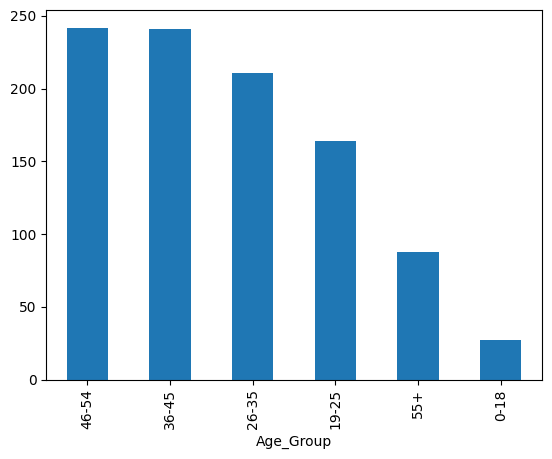

In [84]:
df['Age_Group'].value_counts().plot(kind='bar')

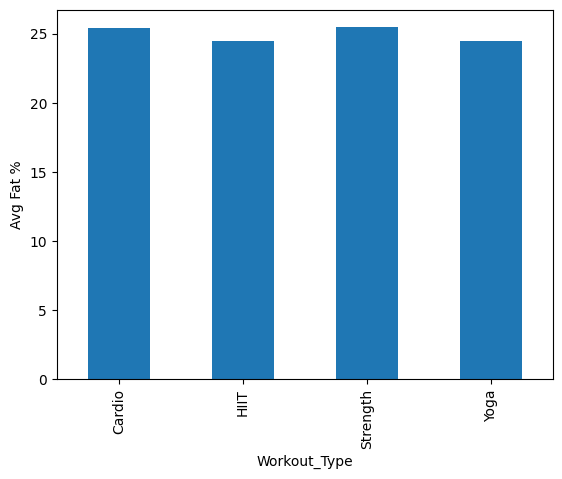

In [85]:
df.groupby('Workout_Type')['Fat_Percentage'].mean().plot(kind='bar')
plt.ylabel('Avg Fat %')
plt.show()

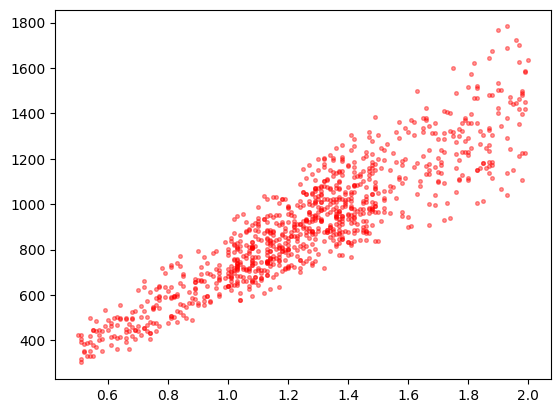

In [86]:
#longer workout burn more calories
plt.scatter(df['Session_Duration (hours)'],df['Calories_Burned'],s=7,color='red',alpha=.4)
plt.show()

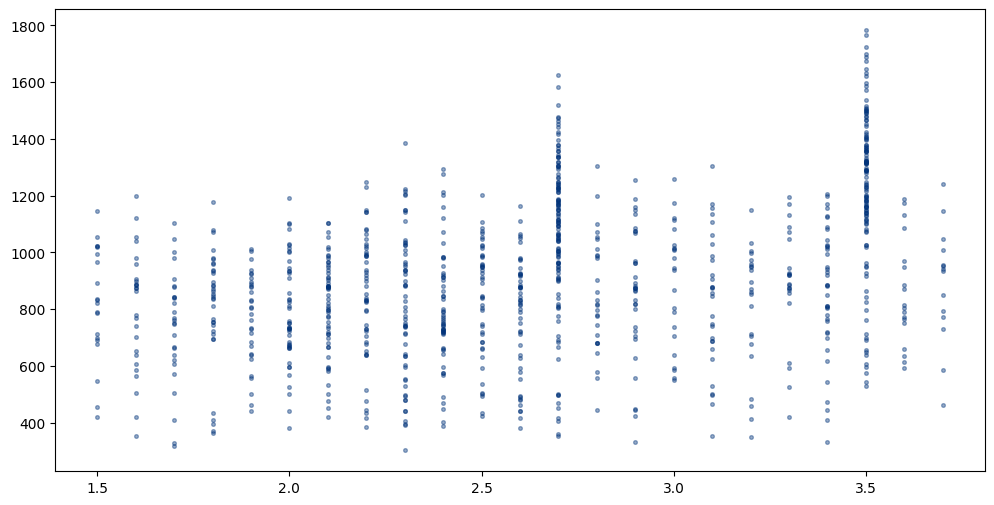

In [87]:
#water intake for how much a colories is burned
plt.figure(figsize=(12,6))
plt.scatter(df['Water_Intake (liters)'],df['Calories_Burned'],s=7,color="#01337A",alpha =.4)

(array([23., 23.,  0., 16., 17.,  0., 12.,  0., 21., 18.,  0., 21.,  0.,
        22., 25.,  0., 26., 23.,  0., 27.,  0., 17., 18.,  0., 24.,  0.,
        24., 23.,  0., 20.,  0., 25., 16.,  0., 21., 16.,  0., 21.,  0.,
        19., 17.,  0., 13.,  0., 18., 17.,  0., 20., 20.,  0., 15.,  0.,
        20., 21.,  0., 13.,  0., 20., 21.,  0., 21.,  0., 24., 12.,  0.,
        21., 24.,  0., 19.,  0., 14., 10.,  0., 19.,  0., 19., 22.,  0.,
        22., 13.]),
 array([120.    , 120.6125, 121.225 , 121.8375, 122.45  , 123.0625,
        123.675 , 124.2875, 124.9   , 125.5125, 126.125 , 126.7375,
        127.35  , 127.9625, 128.575 , 129.1875, 129.8   , 130.4125,
        131.025 , 131.6375, 132.25  , 132.8625, 133.475 , 134.0875,
        134.7   , 135.3125, 135.925 , 136.5375, 137.15  , 137.7625,
        138.375 , 138.9875, 139.6   , 140.2125, 140.825 , 141.4375,
        142.05  , 142.6625, 143.275 , 143.8875, 144.5   , 145.1125,
        145.725 , 146.3375, 146.95  , 147.5625, 148.175 , 148.7875

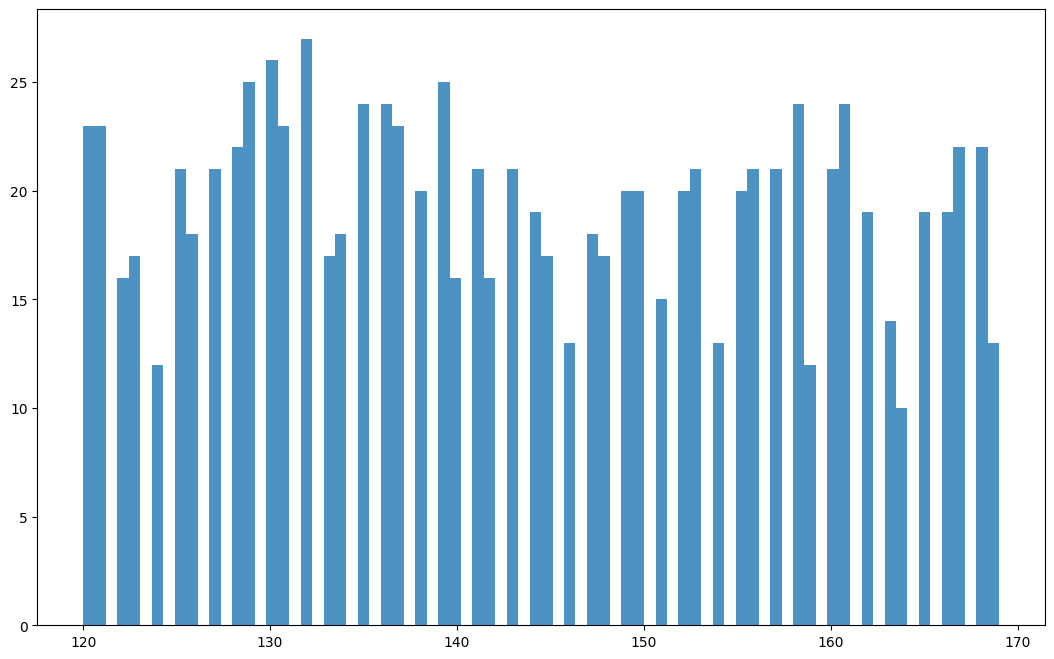

In [88]:
#heart rate during the workout time
plt.figure(figsize=(13,8))
plt.hist(df['Avg_BPM'],bins=80,alpha=.8)


In [89]:
df['BMI']=df['Weight (kg)']/(df['Height (m)']**2)

In [90]:
df['BMI'].mean()

np.float64(24.912238973294375)

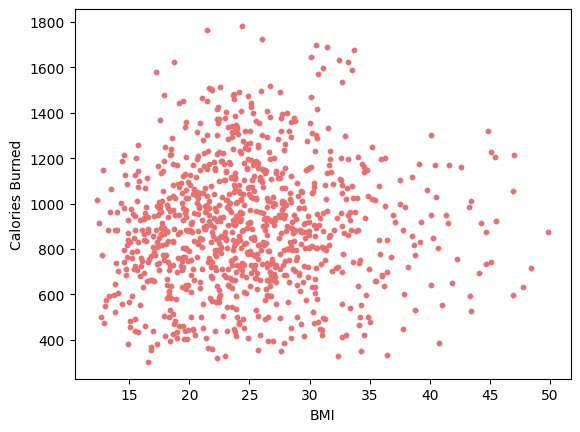

In [91]:
plt.scatter(df['BMI'],df['Calories_Burned'],alpha=1,s=10,color="#E57171")
plt.xlabel('BMI')
plt.ylabel('Calories Burned')
plt.show()

In [92]:
#average calries burned by experience
df.groupby('Experience_Level')['Calories_Burned'].mean()

Experience_Level
1     726.375000
2     901.918719
3    1265.340314
Name: Calories_Burned, dtype: float64

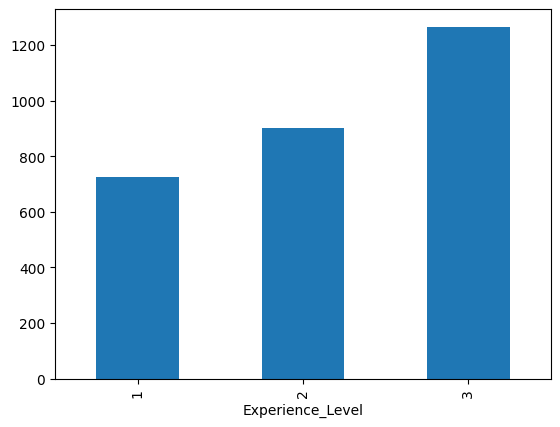

In [93]:
df.groupby('Experience_Level')['Calories_Burned'].mean().plot(kind='bar')
plt.show()

In [94]:
df['Gender'].value_counts()

Gender
Male      511
Female    462
Name: count, dtype: int64

In [95]:
df.groupby('Gender')['Calories_Burned'].mean()

Gender
Female    862.248918
Male      944.455969
Name: Calories_Burned, dtype: float64

In [96]:
df.groupby('Gender')['Calories_Burned'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,462.0,862.248918,249.614915,303.0,710.25,867.0,1016.0,1625.0
Male,511.0,944.455969,286.590987,331.0,742.00,937.0,1138.5,1783.0


In [97]:
#now checking gender wise fat
df.groupby('Gender')['Fat_Percentage'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,462.0,27.656710,5.708223,15.0,25.625,28.9,32.2,35.0
Male,511.0,22.553816,5.729882,10.0,20.700,23.8,27.2,30.0


In [98]:
#tell what they prefers
pd.crosstab(df['Gender'], df['Workout_Type'])

Workout_Type,Cardio,HIIT,Strength,Yoga
Gender,,,,
Female,126,107,123,106
Male,129,114,135,133


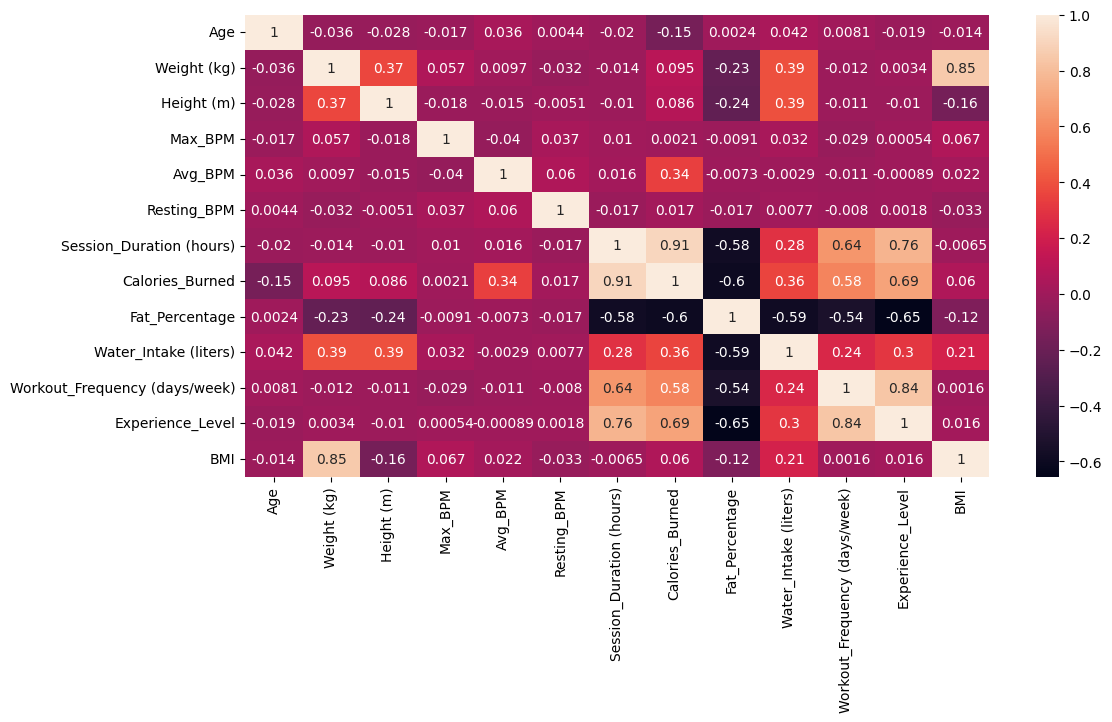

In [99]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True)
plt.show()

In [100]:
df.groupby('Experience_Level')['Fat_Percentage'].mean()
#relation bettwen experience and body fat 

Experience_Level
1    27.634574
2    27.307389
3    14.790576
Name: Fat_Percentage, dtype: float64

<Axes: xlabel='Calories_Burned'>

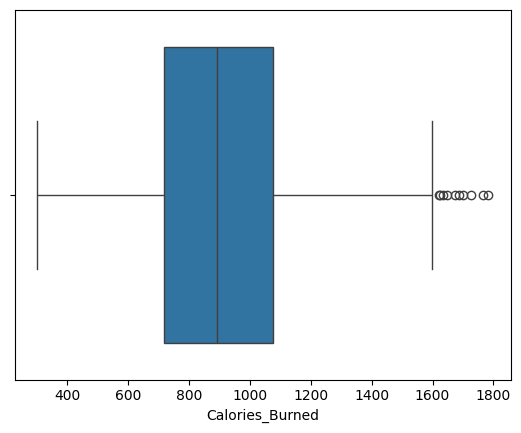

In [101]:
sns.boxplot(x=df['Calories_Burned'])

<Axes: >

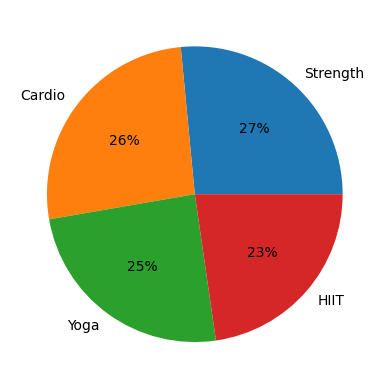

In [108]:
df['Workout_Type'].value_counts().plot(kind='pie',autopct='%1.0f%%')